In [1]:
#NATURAL LANGUAGE TOOLKIT 
import nltk
print(nltk.__version__)

3.10.0


In [2]:
#OBTAINING LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import string
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
nltk.download('stopwords')

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import warnings
warnings.filterwarnings('ignore')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gab\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
#OBTAINING AND VIEWING DATA
email=pd.read_csv('mail_data.csv')
email.head(5)

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


<Axes: xlabel='Category', ylabel='count'>

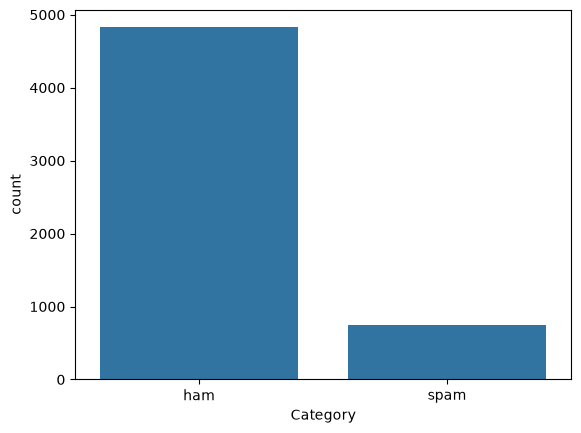

In [4]:
#VIEW OF UNBALANCED DATA
sns.countplot(x='Category',data=email)

In [5]:
#BALANCING OF DATA
ham_msg=email[email['Category']== 'ham']
spam_msg=email[email['Category']=='spam']
ham_msgb=ham_msg.sample(n=len(spam_msg),random_state=30)
email_bal=pd.concat([ham_msgb,spam_msg]).reset_index(drop=True)
email_bal.head(5)
#sns.countplot(x='Category',data=email_bal)

,Category,Message
0,ham,Can you pls send me that company name. In saib...
1,ham,Pls go there today &lt;#&gt; . I dont want an...
2,ham,Armand says get your ass over to epsilon
3,ham,Am on the uworld site. Am i buying the qbank o...
4,ham,I'm e person who's doing e sms survey...


In [6]:
#REMOVAL OF PUNCTUATIONS
punc_list= string.punctuation
def remove_punc(st):
    func=str.maketrans("","",punc_list)
    return st.translate(func)

email_bal['Message']=email_bal['Message'].apply(lambda x:remove_punc(x))
email_bal.head(5)



,Category,Message
0,ham,Can you pls send me that company name In saiba...
1,ham,Pls go there today ltgt I dont want any excuses
2,ham,Armand says get your ass over to epsilon
3,ham,Am on the uworld site Am i buying the qbank on...
4,ham,Im e person whos doing e sms survey


In [7]:
#REMOVAL OF STOPWORDS
def remove_stpw(st):
    stwp=stopwords.words('english')
    colword=[]
    for word in str(st).split():
        word=word.lower()
        if word not in stwp:
            colword.append(word)

    output=" ".join(colword)
    return output

email_bal['Message']=email_bal['Message'].apply(lambda x: remove_stpw(x))
email_bal.head(5)


,Category,Message
0,ham,pls send company name saibaba colany
1,ham,pls go today ltgt dont want excuses
2,ham,armand says get ass epsilon
3,ham,uworld site buying qbank buying self assessmen...
4,ham,im e person whos e sms survey


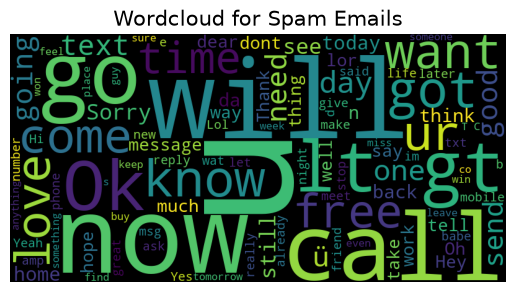

In [8]:
#WORDCLOUD PLOT
def plot_wc(dat,ty):
    email_c=" ".join(email['Message'])
    wc=WordCloud(background_color='black',max_words=100,height=400,width=800).generate(email_c)
    #plt.figure(figsize=(7,7))
    plt.imshow(wc)#,interpolation='bilinear')
    plt.title(f'Wordcloud for {ty} Emails',fontsize=15)
    plt.axis('off')
    plt.show

plot_wc(email_bal[email_bal['Category']=='ham'],'Non-Spam')
plot_wc(email_bal[email_bal['Category']=='spam'],'Spam')
                     

In [9]:
#DATA SPLITTING AND TOKENIZING
train_X,test_X,train_Y,test_Y=train_test_split(email_bal['Message'],email_bal['Category'],test_size=0.2,random_state=30)
tokenizer=Tokenizer(num_words=2000)
tokenizer.fit_on_texts(train_X)
train_sequence=tokenizer.texts_to_sequences(train_X)
test_sequence=tokenizer.texts_to_sequences(test_X)
#BALANCED DATA PADDING
train_sequence=pad_sequences(train_sequence,maxlen=100,padding='post',truncating='post')
test_sequence=pad_sequences(test_sequence,maxlen=100,padding='post',truncating='post')

train_Y=(train_Y=='spam').astype(int)
test_Y=(test_Y=='spam').astype(int)

In [10]:
#DATA MODELLING
model=tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(100,)),
    tf.keras.layers.Embedding(len(tokenizer.word_index)+1,16),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(16,activation='relu'),
    tf.keras.layers.Dense(1,activation='sigmoid')
])
#MODEL OPTIMIZING
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
model.summary()

small_X = train_sequence[:100]
small_Y = train_Y[:100]
#TRAINING DATA
history = model.fit(
    train_sequence,
    train_Y,
    validation_data=(test_sequence,test_Y),
    epochs=32,
    batch_size=32
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 100, 16)             │          64,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 16)                  │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 64,977 (253.82 KB)

 Trainable params: 64,977 (253.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/32
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.4879 - loss: 0.6929 - val_accuracy: 0.5151 - val_loss: 0.6884
Epoch 2/32
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4979 - loss: 0.6886 - val_accuracy: 0.5151 - val_loss: 0.6849
Epoch 3/32
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4996 - loss: 0.6833 - val_accuracy: 0.6823 - val_loss: 0.6805
Epoch 4/32
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5967 - loss: 0.6759 - val_accuracy: 0.7659 - val_loss: 0.6706
Epoch 5/32
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7013 - loss: 0.6631 - val_accuracy: 0.5485 - val_loss: 0.6537
Epoch 6/32
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7607 - loss: 0.6416 - val_accuracy: 0.8930 - val_loss: 0.6297
Epoch 7/32
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8326 - loss: 0.6051 - val_accuracy: 0.9398 - val_loss: 0.5981
Epoch 8/32
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8887 - loss: 0.5592 - val_accuracy: 0.8395 - val_loss

In [11]:
print(tf.__version__)
print(tf.keras.__version__)
pred = model.predict(test_sequence[:20])
#MODEL PREDICTION
print(pred.flatten())
print(history.history['accuracy'])
#print(history.history['val_accuracy'])
pred = (model.predict(small_X) > 0.5).astype(int)

print(np.unique(pred, return_counts=True))
print(email_bal['Category'].value_counts())
pred = model.predict(small_X[:20])
print(pred.flatten())
#TROUBLESHOOTING
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

vectorizer = TfidfVectorizer(max_features=2000)

X_train = vectorizer.fit_transform(train_X)
X_test = vectorizer.transform(test_X)

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, train_Y)

pred = lr.predict(X_test)

print("Accuracy:", accuracy_score(test_Y, pred))

2.21.0
3.15.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
[0.02525811 0.96603197 0.89134306 0.02896166 0.05224998 0.01945839
 0.01875759 0.9914836  0.14000131 0.9641417  0.99697983 0.1175134
 0.9988486  0.998512   0.69086623 0.02865373 0.9978374  0.95597994
 0.19888075 0.9207713 ]
[0.4878661036491394, 0.49790793657302856, 0.49958157539367676, 0.5966527462005615, 0.701255202293396, 0.760669469833374, 0.8326359987258911, 0.888702929019928, 0.897071123123169, 0.9146443605422974, 0.92384934425354, 0.9271966814994812, 0.9414225816726685, 0.9414225816726685, 0.9447698593139648, 0.9456067085266113, 0.9506276249885559, 0.9531380534172058, 0.9573221802711487, 0.9606694579124451, 0.9623430967330933, 0.9623430967330933, 0.9648535847663879, 0.9665272235870361, 0.9631799459457397, 0.9631799459457397, 0.9682008624076843, 0.9665272235870361, 0.9648535847663879, 0.9648535847663879, 0.9707112908363342, 0.9707112908363342]
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
(array([0, 1]), array([44, 56]))
Category
ham   

#es=EarlyStopping(patience=3,monitor='val_accuracy',restore_best_weights=True)
#ir=ReduceLROnPlateau(patience=2,monitor='val_loss',factor=0.5,verbose=0)
history= model.fit(
    train_sequence,train_Y,
    validation_data=(test_sequence,test_Y),
    epochs=40,
    batch_size=32,
    callbacks=[ir,es]
)


test_loss,test_accuracy=model.evaluate(test_sequence,test_Y)
print(test_loss)
print(test_accuracy)

In [32]:
#LINEAR REGRESSION TESTING AGAINST GLOBALAVERAGEPOOLINGID
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
scaler=StandardScaler()
lr=LogisticRegression()
lrx=scaler.fit_transform(train_sequence)
lr.fit(lrx,train_Y)
print('Training Accuracy:',metrics.roc_auc_score(train_Y,lr.predict_proba(lrx)[:,1]))
print('Validation Accuracy:',metrics.roc_auc_score(test_Y,lr.predict_proba(test_sequence)[:,1]))
from sklearn.metrics import classification_report

pred = lr.predict(test_sequence)

print(classification_report(test_Y, pred))
#pred = model.predict(test_sequence)

#print(classification_report(test_Y, pred))

Training Accuracy: 0.8567184707523545
Validation Accuracy: 0.8053739364084193
              precision    recall  f1-score   support

           0       0.74      0.87      0.80       154
           1       0.83      0.68      0.75       145

    accuracy                           0.78       299
   macro avg       0.79      0.77      0.77       299
weighted avg       0.78      0.78      0.77       299

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


ValueError: Classification metrics can't handle a mix of binary and continuous targets